# Examen Parcial - Unidad 1
## Red Siamesa rPPG Hiperespectral en Zonas Plantares

**Alumno:** Victoria Galván Delgadillo  


### Objetivo
Estimar de forma no invasiva la señal de fotopletismografía remota (rPPG) y la frecuencia cardíaca mediante el uso de redes siamesas, a partir de secuencias de parches hiperespectrales extraídos de las regiones de interés (ROI) plantares $z2$ y $z3$.


## 1. Configuración del Experimento 1

En esta sección se establecen las rutas de acceso al conjunto de datos y los hiperparámetros globales que rigen el entrenamiento y la evaluación del modelo.

### Distribución de Participantes por Conjunto

A continuación se detalla el número de participantes únicos (*sujetos*) y el total de ventanas temporales registradas en cada partición del dataset:

* **Entrenamiento (`train`):** 
  * Participantes: **17**
  * Ventanas / Archivos: **23,214**
* **Validación (`val`):** 
  * Participantes: **6**
  * Ventanas / Archivos: **7,188**
* **Prueba (`test`):** 
  * Participantes: **3** (P9_D, P17, P28)
  * Ventanas / Archivos: **3,799**

**Total general:** 26 participantes distribuidos en los tres conjuntos del experimento.

In [2]:
%matplotlib inline
import os
import glob
from collections import defaultdict
from dataclasses import dataclass
import matplotlib
#matplotlib.use('Agg')  
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)
from scipy.signal import butter, filtfilt

EPS = 1e-7

@dataclass(frozen=True)
class Config:
    dataset_path: str = r"/home/laboratorio/datos"
    output_dir: str = r"/home/laboratorio"

    zones = ("z2", "z3")
    bands = 42 # numero de canales
    patch = 20 # parches recortados de z2 y z3  (parches cuadrados de 20x20)
    invalid = -1.0 

    timesteps = 100 # longitu de la venatana ahora con 100 frames que equivale a 20 segundos
    train_stride = 1 #stride no reportado en el paper, se deja en 1 para maximizar el solapamiento entre ventanas.
    eval_stride = 5 # Paso de desplazamiento por ventana 
    batch_size = 32 # Muestras temporales en cada paso
    epochs = 500 # EN el paper usar 250 epochs 
    lr = 1e-4 # learning rate 
    margin_frames = 30 #Ignoramos los primeros 30 frames 
    fs = 5.0 # Frecuencia de muestreo de la cámara 
    seed = 42 #Aleatoriedad de los datos

ModuleNotFoundError: No module named 'tensorflow'

## 2. Datos y Preprocesamiento

El pipeline de procesamiento implementa la carga recursiva de archivos `.npz` y la construcción de generadores optimizados con `tf.data.Dataset`. Sus etapas críticas comprenden:

* **Estandarización por sujeto:** Normalización y escalamiento de los parches hiperespectrales para mantener la consistencia en los rangos de intensidad lumínica y reflectancia de la piel.
* **Manejo de valores inválidos:** Sustitución de píxeles nulos o corruptos (`invalid = -1.0`) mediante el cálculo de la media de las bandas espectrales seleccionadas (`compute_band_means`).
* **Filtrado Fisiológico y Señal de Referencia (Butterworth Pasabanda):** 
  * Se aplica un filtro digital Butterworth de orden 3 en el rango estricto de **$0.7\text{ Hz}$ a $2.0\text{ Hz}$** ($42$ a $120\text{ bpm}$).
  * **Característica crítica de la referencia ($y$):** Los datos de la señal $y$ provienen directamente del sensor físico de contacto ubicado en el dedo gordo, correspondiendo estrictamente a la componente pulsátil AC limpia (exenta de la componente basal).
  * **Justificación metodológica:** Volver a aplicar este estándar de filtrado garantiza una simetría frente a las predicciones de la red, asegurando que tanto la referencia como la salida compartan la misma banda de frecuencia cardíaca.


In [ ]:
def butter_bandpass_filter(data, lowcut=0.7, highcut=2.0, fs=5.0, order=3):
    """ Filtro pasabanda para aislar la componente cardiaca (0.7 a 2.0 Hz"""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)
    
def list_split(cfg, split):
    ruta = os.path.join(cfg.dataset_path, split, "**", "*.npz")
    return sorted(glob.glob(ruta, recursive=True))

def check_keys(cfg, files):
    if len(cfg.zones) != 2:
        raise ValueError("La red siamesa necesita exactamente dos zonas.")
    expected = (1, cfg.patch, cfg.patch, cfg.bands)
    with np.load(files[0]) as d:
        for z in cfg.zones:
            if z not in d.files:
                raise KeyError(f"La zona '{z}' no está en el .npz")
            if d[z].shape != expected:
                raise ValueError(f"'{z}' tiene forma {d[z].shape}, se esperaba {expected}")

def group_by_participant(files):
    groups = defaultdict(list)
    for path in files:
        with np.load(path) as d:
            groups[str(d["base"])].append((int(d["start"]), path))
    return {name: [p for _, p in sorted(items)] for name, items in groups.items()}

def compute_band_means(cfg, groups):
    total = np.zeros(cfg.bands, dtype=np.float64)
    count = np.zeros(cfg.bands, dtype=np.float64)
    for paths in groups.values():
        for path in paths:
            with np.load(path) as d:
                for z in cfg.zones:
                    patch = d[z][0].astype(np.float64)
                    valid = patch != cfg.invalid
                    total += np.where(valid, patch, 0.0).sum(axis=(0, 1))
                    count += valid.sum(axis=(0, 1))
    return (total / np.maximum(count, 1)).astype(np.float32)

def fill_invalid(patch, band_mean, invalid):
    return np.where(patch == invalid, band_mean, patch).astype(np.float32)

def load_series(cfg, paths, band_mean):
    n = len(paths)
    zones = [np.empty((n, cfg.patch, cfg.patch, cfg.bands), np.float32) for _ in cfg.zones]
    y = np.empty(n, np.float32)
    for i, path in enumerate(paths):
        with np.load(path) as d:
            for k, z in enumerate(cfg.zones):
                zones[k][i] = fill_invalid(d[z][0].astype(np.float32), band_mean, cfg.invalid)
            y[i] = d["y"][0, 0]
    return zones, y

@dataclass
class ParticipantInfo:
    paths: list
    zone_mean: list
    zone_std: list
    y_mean: float
    y_std: float
    @property
    def n(self):
        return len(self.paths)

def build_table(cfg, groups, band_mean):
    table = {}
    for name, paths in groups.items():
        zones, y_raw = load_series(cfg, paths, band_mean)
        y_filtered = butter_bandpass_filter(y_raw, lowcut=0.7, highcut=2.0, fs=cfg.fs)
        table[name] = ParticipantInfo(
            paths=paths,
            zone_mean=[z.mean(axis=0, dtype=np.float64).astype(np.float32) for z in zones],
            zone_std=[z.std(axis=0, dtype=np.float64).astype(np.float32) + EPS for z in zones],
            y_mean=float(y_filtered.mean()),
            y_std=float(y_filtered.std()) + EPS,
        )
    return table

def load_normalized(cfg, info, band_mean):
    zones, y_raw = load_series(cfg, info.paths, band_mean)
    for z, m, s in zip(zones, info.zone_mean, info.zone_std):
        z -= m
        z /= s
    y_filtered = butter_bandpass_filter(y_raw, lowcut=0.7, highcut=2.0, fs=cfg.fs)
    return zones, y_filtered

def window_generator(cfg, table, band_mean, stride, shuffle):
    names = list(table)
    if shuffle:
        np.random.shuffle(names)
    for name in names:
        info = table[name]
        effective_n = info.n - 2 * cfg.margin_frames
        if effective_n < cfg.timesteps:
            continue
            
        (za, zb), y_filtered = load_normalized(cfg, info, band_mean)
        y_norm = (y_filtered - info.y_mean) / info.y_std
        
        starts = np.arange(cfg.margin_frames, info.n - cfg.margin_frames - cfg.timesteps + 1, stride)
        if shuffle:
            np.random.shuffle(starts)
        for s in starts:
            e = s + cfg.timesteps
            yield (za[s:e], zb[s:e]), y_norm[s:e]

def make_dataset(cfg, table, band_mean, shuffle):
    shape = (cfg.timesteps, cfg.patch, cfg.patch, cfg.bands)
    signature = (
        (tf.TensorSpec(shape, tf.float32), tf.TensorSpec(shape, tf.float32)),
        tf.TensorSpec((cfg.timesteps,), tf.float32),
    )
    ds = tf.data.Dataset.from_generator(
        lambda: window_generator(cfg, table, band_mean, cfg.train_stride, shuffle),
        output_signature=signature,
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=8, reshuffle_each_iteration=True)
    return ds.batch(cfg.batch_size).prefetch(1)


## 3. Pérdida y Métricas

La optimización del modelo y su posterior evaluación de rendimiento se fundamentan en métricas diseñadas específicamente para capturar la fidelidad morfológica y temporal de las señales hemodinámicas:

* **Función de Pérdida (Correlación de Pearson Negativa, $1 - r$):**
  * **Definición matemática:** Siguiendo la metodología de Tsou et al., la red minimiza la función de pérdida $L = 1 - r$, donde $r$ representa el coeficiente de correlación lineal de Pearson entre la señal real y la predicha.
  * **Justificación metodológica:** Al penalizar la falta de correlación lineal, se fuerza a la red a aprender la fase y la morfología periódica de la onda de pulso rPPG, evitando que el modelo optimice únicamente escalando amplitudes o cayendo en soluciones triviales de magnitud.
* **Métricas Auxiliares de Error Temporal:**
  * **MAE (Error Absoluto Medio):** Mide la magnitud promedio de los errores absolutos punto a punto entre la onda predicha y la referencia, sin penalizar de forma cuadrática los desvíos atípicos.
  * **RMSE (Raíz del Error Cuadrático Medio):** Cuantifica la desviación estándar de los residuos (errores de reconstrucción), otorgando mayor peso a los errores grandes y asegurando la estabilidad en la forma de la onda reconstrucida.


In [ ]:
def pearson_r(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    yt = y_true - tf.reduce_mean(y_true, axis=-1, keepdims=True)
    yp = y_pred - tf.reduce_mean(y_pred, axis=-1, keepdims=True)
    num = tf.reduce_sum(yt * yp, axis=-1)
    den = tf.sqrt(tf.reduce_sum(yt ** 2, axis=-1) + 1e-8) * \
          tf.sqrt(tf.reduce_sum(yp ** 2, axis=-1) + 1e-8)
    return tf.reduce_mean(num / (den + 1e-8))

def negative_pearson_loss(y_true, y_pred):
    return 1.0 - pearson_r(y_true, y_pred)

def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred), axis=-1))

## 4. Arquitectura de la Red

A diferencia de la arquitectura Conv3D completa tradicional (como la reportada en la literatura de referencia), este modelo implementa una estrategia híbrida: colapsa la dimensión espacial (alto y ancho) de manera temprana tras tres bloques Conv3D, modelando posteriormente la periodicidad temporal mediante convoluciones unidimensionales (`Conv1D`).

* **Ramas Gemelas:** Estructura con pesos compartidos y dos entradas independientes para procesar en paralelo las dos regiones de interés plantares ($z2$ y $z3$).
* **Bloques Espaciotemporales (Conv3D):**
  * **Bloque 1:** 8 filtros, kernel $(3,3,3)$, activación `leaky_relu`, seguido de `AveragePooling3D` espacial de $(1,2,2)$.
  * **Bloque 2:** 16 filtros, kernel $(3,3,3)$, activación `leaky_relu`, seguido de `AveragePooling3D` espacial de $(1,2,2)$.
  * **Bloque 3:** 32 filtros, kernel $(3,3,3)$, activación `leaky_relu`, seguido de `AveragePooling3D` espacial de $(1,2,2)$.
* **Colapso Espacial Temprano (Capa Lambda):** Se promedia la dimensión espacial de alto y ancho (`axis=[2, 3]`), transformando el tensor tridimensional en una secuencia estrictamente temporal.
* **Procesamiento Temporal (Conv1D):** Capa de 16 filtros, tamaño de kernel de $5$ y activación `leaky_relu` para aprender la periodicidad temporal de la onda sin requerir bloques 3D adicionales.
* **Fusión y Suavizado Final:**
  * Las señales de ambas ramas se combinan mediante una suma elemento a elemento (`layers.Add()`).
  * Se aplica un filtro `Conv1D` final de 1 canal con un kernel de $3$ para suavizar la onda de pulso rPPG resultante antes de la capa de salida.


In [ ]:
def create_siamese_branch(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = inputs

    x = layers.Conv3D(8, (3, 3, 3), padding="same", activation="leaky_relu")(x)
    x = layers.AveragePooling3D(pool_size=(1, 2, 2), strides=(1, 2, 2), padding="same")(x)

    x = layers.Conv3D(16, (3, 3, 3), padding="same", activation="leaky_relu")(x)
    x = layers.AveragePooling3D(pool_size=(1, 2, 2), strides=(1, 2, 2), padding="same")(x)

    x = layers.Conv3D(32, (3, 3, 3), padding="same", activation="leaky_relu")(x)
    x = layers.AveragePooling3D(pool_size=(1, 2, 2), strides=(1, 2, 2), padding="same")(x)

    # Colapso espacial 
    x = layers.Lambda(lambda t: tf.reduce_mean(t, axis=[2, 3]))(x)

    x = layers.Dropout(0.4)(x)

    # Filtro temporal 1D integrado
    x = layers.Conv1D(filters=16, kernel_size=5, padding="same", activation="leaky_relu")(x)

    x = layers.Dense(1, activation=None)(x)
    x = layers.Flatten()(x)
    return Model(inputs=inputs, outputs=x, name="Siamese_Branch_Reducida")


def crear_modelo(input_shape, learning_rate=1e-4):
    branch = create_siamese_branch(input_shape)

    roi_1 = layers.Input(shape=input_shape, name="ROI_1")
    roi_2 = layers.Input(shape=input_shape, name="ROI_2")

    out = layers.Add(name="rppg_addition")([branch(roi_1), branch(roi_2)])

    # Suavizado final
    out_expanded = layers.Reshape((-1, 1))(out)
    out_filtered = layers.Conv1D(1, kernel_size=3, padding="same", use_bias=False)(out_expanded)
    final_signal = layers.Flatten(name="final_rppg")(out_filtered)

    model = Model(inputs=[roi_1, roi_2], outputs=final_signal, name="Siamese_rPPG_Hyperspectral")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=negative_pearson_loss,
        metrics=["mae", rmse, pearson_r],
    )
    return model

## 5. Evaluación, FFT y Gráficas

Bloque destinado a la inferencia sobre secuencias completas y análisis de resultados experimentales:

* **Reconstrucción de Señales:** Las predicciones del modelo se procesan a través de ventanas deslizantes superpuestas, se desnormalizan y se someten exactamente al mismo filtro pasabanda fisiológico (`Butterworth` de $0.7\text{ Hz}$ a $2.0\text{ Hz}$) aplicado a la señal de referencia, garantizando total simetría en la comparación.
* **Análisis Espectral (Transformada Rápida de Fourier  FFT):** 
  * Permite calcular la frecuencia cardíaca dominante ($\text{HR}$) tanto en la señal real como en la predicha, transformando el dominio temporal al dominio de la frecuencia.
* **Métricas Clínicas de Precisión:**
  * **$\text{HR MAE}$ y $\text{HR RMSE}$:** Cuantifican el error absoluto medio y la raíz del error cuadrático medio expresados directamente en latidos por minuto ($\text{bpm}$).
  * **Precisión Estricta ($\pm 2.5\text{ bpm}$ y $\pm 5.0\text{ bpm}$):** Porcentaje de muestras o sujetos cuyas estimaciones de frecuencia cardíaca se encuentran dentro de los márgenes de tolerancia establecidos por la literatura de referencia.


In [ ]:
def estimate_heart_rate(signal, fs, min_bpm=40, max_bpm=150):
    x = np.asarray(signal, dtype=np.float64)
    x = x - np.mean(x)
    
    if len(x) == 0:
        return np.nan
        
    x = x * np.hanning(len(x))
    n = len(x)
    fft_vals = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)

    bpm_axis = freqs * 60.0
    mask = (bpm_axis >= min_bpm) & (bpm_axis <= max_bpm)
    if not np.any(mask):
        return np.nan

    magnitude = np.abs(fft_vals)
    magnitude_masked = magnitude.copy()
    magnitude_masked[~mask] = 0.0

    peak_idx = np.argmax(magnitude_masked)
    return float(bpm_axis[peak_idx])

def pearson_np(a, b):
    a = np.asarray(a, dtype=np.float64) - np.mean(a)
    b = np.asarray(b, dtype=np.float64) - np.mean(b)
    return float(np.sum(a * b) / (np.sqrt(np.sum(a ** 2)) * np.sqrt(np.sum(b ** 2)) + 1e-12))


def null_test_pearson(y_true, y_pred, shift_frames=150):
    """R con la predicción desplazada en el tiempo (30 s a fs=5 Hz). Si se
    parece a la R real, la R real probablemente es ruido, no señal."""
    shifted = np.roll(y_pred, shift_frames)
    return pearson_np(y_true, shifted)


def baseline_mean_roi(cfg, zones_raw):
    """Señal más simple posible: promedio de píxeles/bandas de ambas ROI,
    filtrada igual que todo lo demás. No usa la etiqueta y para nada."""
    mean_signal = np.mean([z.mean(axis=(1, 2, 3)) for z in zones_raw], axis=0)
    return butter_bandpass_filter(mean_signal, fs=cfg.fs)


def signal_metrics(y_true, y_pred):
    err = np.asarray(y_true, dtype=np.float64) - np.asarray(y_pred, dtype=np.float64)
    return {
        "pearson": pearson_np(y_true, y_pred),
        "mae": float(np.mean(np.abs(err))),
        "rmse": float(np.sqrt(np.mean(err ** 2))),
    }

def reconstruct_signal(cfg, model, zones, n):
    T = cfg.timesteps
    starts = list(range(0, n - T + 1, cfg.eval_stride))
    if starts[-1] != n - T:
        starts.append(n - T)
    acc, cnt = np.zeros(n), np.zeros(n)
    for i in range(0, len(starts), cfg.batch_size):
        chunk = starts[i:i + cfg.batch_size]
        xa = np.stack([zones[0][s:s + T] for s in chunk])
        xb = np.stack([zones[1][s:s + T] for s in chunk])
        preds = model.predict([xa, xb], verbose=0)
        for s, p in zip(chunk, preds):
            acc[s:s + T] += p
            cnt[s:s + T] += 1
    return acc / cnt

def precision_at_t_bpm(hr_true_list, hr_pred_list, t=5.0):
    hr_true = np.asarray(hr_true_list, dtype=np.float64)
    hr_pred = np.asarray(hr_pred_list, dtype=np.float64)
    valid = ~np.isnan(hr_true) & ~np.isnan(hr_pred)
    if valid.sum() == 0:
        return 0.0
    errors = np.abs(hr_pred[valid] - hr_true[valid])
    return float(np.mean(errors <= t))

def evaluate_test(cfg, model, table, band_mean):
    all_true_waves, all_pred_waves = [], []
    hr_true_list, hr_pred_list = [], []
    null_rs, baseline_rs = [], []

    for name, info in table.items():
        if info.n < cfg.timesteps:
            continue

        zones, y_filtered = load_normalized(cfg, info, band_mean)
        zones_raw, _ = load_series(cfg, info.paths, band_mean)   # sin normalizar, para el baseline
        pred_norm = reconstruct_signal(cfg, model, zones, info.n)

        # Desnormalizar
        y_pred_desnorm = pred_norm * info.y_std + info.y_mean
        
        y_pred_filtered = butter_bandpass_filter(y_pred_desnorm, lowcut=0.7, highcut=2.0, fs=cfg.fs)

        valid_mask = np.zeros(info.n, dtype=bool)
        valid_mask[cfg.margin_frames : info.n - cfg.margin_frames] = True

        y_t_eval = y_filtered[valid_mask]
        y_p_eval = y_pred_filtered[valid_mask]

        # Evaluación Temporal
        m = signal_metrics(y_t_eval, y_p_eval)
        all_true_waves.append(y_t_eval)
        all_pred_waves.append(y_p_eval)

        null_r = null_test_pearson(y_t_eval, y_p_eval)
        base_signal = baseline_mean_roi(cfg, zones_raw)[valid_mask]
        baseline_r = pearson_np(y_t_eval, base_signal)
        null_rs.append(null_r)
        baseline_rs.append(baseline_r)

        hr_true = estimate_heart_rate(y_t_eval, fs=cfg.fs)
        hr_pred = estimate_heart_rate(y_p_eval, fs=cfg.fs)
        hr_true_list.append(hr_true)
        hr_pred_list.append(hr_pred)
        
        hr_err = abs(hr_true - hr_pred) if not np.isnan(hr_true) and not np.isnan(hr_pred) else np.nan

        plt.figure(figsize=(20, 6))
        plt.plot(np.arange(len(y_t_eval)), y_t_eval, label="Hb Real (Filtrada)", linewidth=2)
        plt.plot(np.arange(len(y_p_eval)), y_p_eval, "--", label="Hb Predicha (Filtrada)", linewidth=2)
        plt.xlabel("Frame")
        plt.ylabel("Amplitud AC")
        hr_t_str = f"{hr_true:.1f}" if not np.isnan(hr_true) else "N/A"
        hr_p_str = f"{hr_pred:.1f}" if not np.isnan(hr_pred) else "N/A"
        plt.title(f"{name} | R = {m['pearson']:.3f} | HR Real: {hr_t_str} bpm | HR Pred: {hr_p_str} bpm")
        plt.legend()
        plt.tight_layout()
        
        plt.show()

        err_str = f"{hr_err:.2f}" if not np.isnan(hr_err) else "N/A"
        print(f"{name:12s} | R={m['pearson']:.3f} | R_nulo={null_r:.3f} | R_baseline={baseline_r:.3f} "
              f"| HR Error={err_str} bpm")

    if len(all_true_waves) > 0:
        g = signal_metrics(np.concatenate(all_true_waves), np.concatenate(all_pred_waves))
        g["n_participants"] = len(all_true_waves)
        g["null_r_mean"] = float(np.mean(null_rs)) if null_rs else 0.0
        g["baseline_r_mean"] = float(np.mean(baseline_rs)) if baseline_rs else 0.0
        
        hr_true_arr = np.asarray(hr_true_list)
        hr_pred_arr = np.asarray(hr_pred_list)
        valid = ~np.isnan(hr_true_arr) & ~np.isnan(hr_pred_arr)
        
        if valid.sum() > 0:
            hr_errors = np.abs(hr_pred_arr[valid] - hr_true_arr[valid])
            g["hr_mae"] = float(np.mean(hr_errors))
            g["hr_rmse"] = float(np.sqrt(np.mean(np.square(hr_errors))))
        else:
            g["hr_mae"] = 0.0
            g["hr_rmse"] = 0.0
            
        g["precision_2_5"] = precision_at_t_bpm(hr_true_list, hr_pred_list, t=2.5)
        g["precision_5_0"] = precision_at_t_bpm(hr_true_list, hr_pred_list, t=5.0)
    else:
        g = {"pearson": 0.0, "mae": 0.0, "rmse": 0.0, "n_participants": 0, 
             "hr_mae": 0.0, "hr_rmse": 0.0, "precision_2_5": 0.0, "precision_5_0": 0.0,
             "null_r_mean": 0.0, "baseline_r_mean": 0.0}
    return g

def plot_history(cfg, history):
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, key, title in zip(axes, ("loss", "pearson_r"), ("Pérdida (1 - R)", "Pearson R")):
        ax.plot(h[key], label="train")
        if f"val_{key}" in h:
            ax.plot(h[f"val_{key}"], label="val")
        ax.set_title(title)
        ax.set_xlabel("Época")
        ax.legend()
    plt.tight_layout()
    
    plt.show()


## 7. Configuración de entorno

* **Configuración del Entorno:** Inicialización de dispositivos (GPU/CUDA), establecimiento de semillas aleatorias (`seed = 42`) para asegurar la reproducibilidad de los resultados y gestión de directorios de salida.
* **Estructuración de Datos:** División y agrupamiento de los archivos `.npz` por participantes para los conjuntos de entrenamiento (`Train`), validación (`Val`) y prueba (`Test`), evitando la fuga de datos (*data leakage*) entre particiones.
* **Gestión de Callbacks y Regularización:** Instanciación de herramientas de control durante el entrenamiento:
  * *Early Stopping:* Parada temprana para evitar el sobreajuste si la pérdida en validación deja de mejorar.
  * *ReduceLROnPlateau:* Decaimiento dinámico de la tasa de aprendizaje (`lr`) cuando el modelo se estanca.
  * *Model Checkpoint:* Guardado automático de los mejores pesos del modelo basándose en el rendimiento de validación.
* **Ejecución y Exportación:** Lanzamiento del ciclo de entrenamiento según las épocas configuradas (`epochs = 500`) y posterior inferencia sobre el conjunto de prueba para exportar el reporte final de métricas.

{'train': 23214, 'val': 7188, 'test': 3799}
{'train': 17, 'val': 6, 'test': 3} participantes por conjunto


Model: "Siamese_rPPG_Hyperspectral"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ROI_1 (InputLayer)  │ (None, 100, 20,   │          0 │ -                 │
│                     │ 20, 42)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ROI_2 (InputLayer)  │ (None, 100, 20,   │          0 │ -                 │
│                     │ 20, 42)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Siamese_Branch_Red… │ (None, 100)       │     29,001 │ ROI_1[0][0],      │
│ (Functional)        │                   │            │ ROI_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rppg_addition (Add) │ (None, 100)       │          0 │ Siamese_Branch_R… │
│                     │                   │            │ Siamese_Branch_R… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 100, 1)    │          0 │ rppg_addition[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 100, 1)    │          3 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_rppg          │ (None, 100)       │          0 │ conv1d_5[0][0]    │
│ (Flatten)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,004 (113.30 KB)

 Trainable params: 29,004 (113.30 KB)

...

2026-09-23 12:28:37.415160: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10112262330586422669
2026-09-23 12:28:37.415201: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4880849164890905010
2026-09-23 12:28:37.415206: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 9583430909590528928


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - loss: 0.7074 - mae: 0.6523 - pearson_r: 0.2926 - rmse: 0.8749

2026-09-23 12:29:18.069323: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10112262330586422669
2026-09-23 12:29:18.069343: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4880849164890905010
2026-09-23 12:29:18.069351: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 9583430909590528928



Epoch 36: val_loss did not improve from 0.98689
129/129 ━━━━━━━━━━━━━━━━━━━━ 53s 400ms/step - loss: 0.7074 - mae: 0.6522 - pearson_r: 0.2926 - rmse: 0.8749 - val_loss: 1.0179 - val_mae: 0.6223 - val_pearson_r: -0.0184 - val_rmse: 0.8564 - learning_rate: 1.2500e-05
Epoch 36: early stopping
Restoring model weights from the end of the best epoch: 6.


2026-09-23 12:29:30.343203: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10112262330586422669
2026-09-23 12:29:30.343225: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4880849164890905010
2026-09-23 12:29:30.343229: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 9583430909590528928


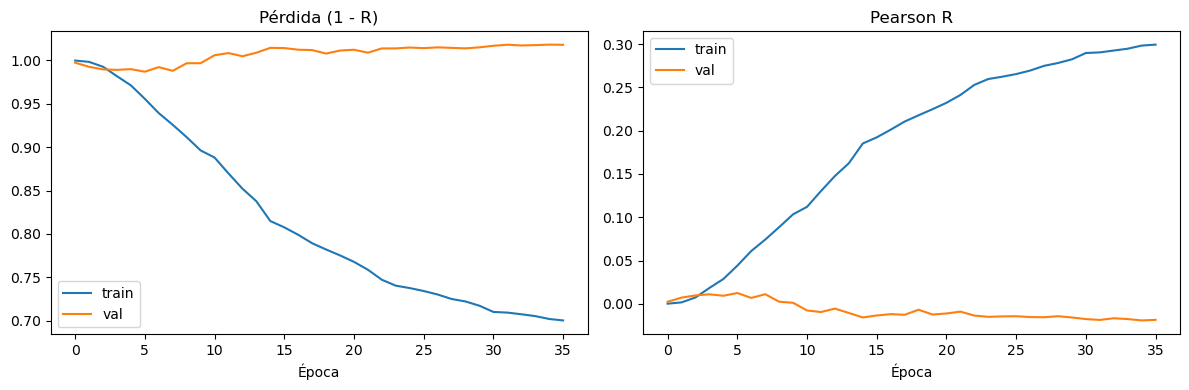

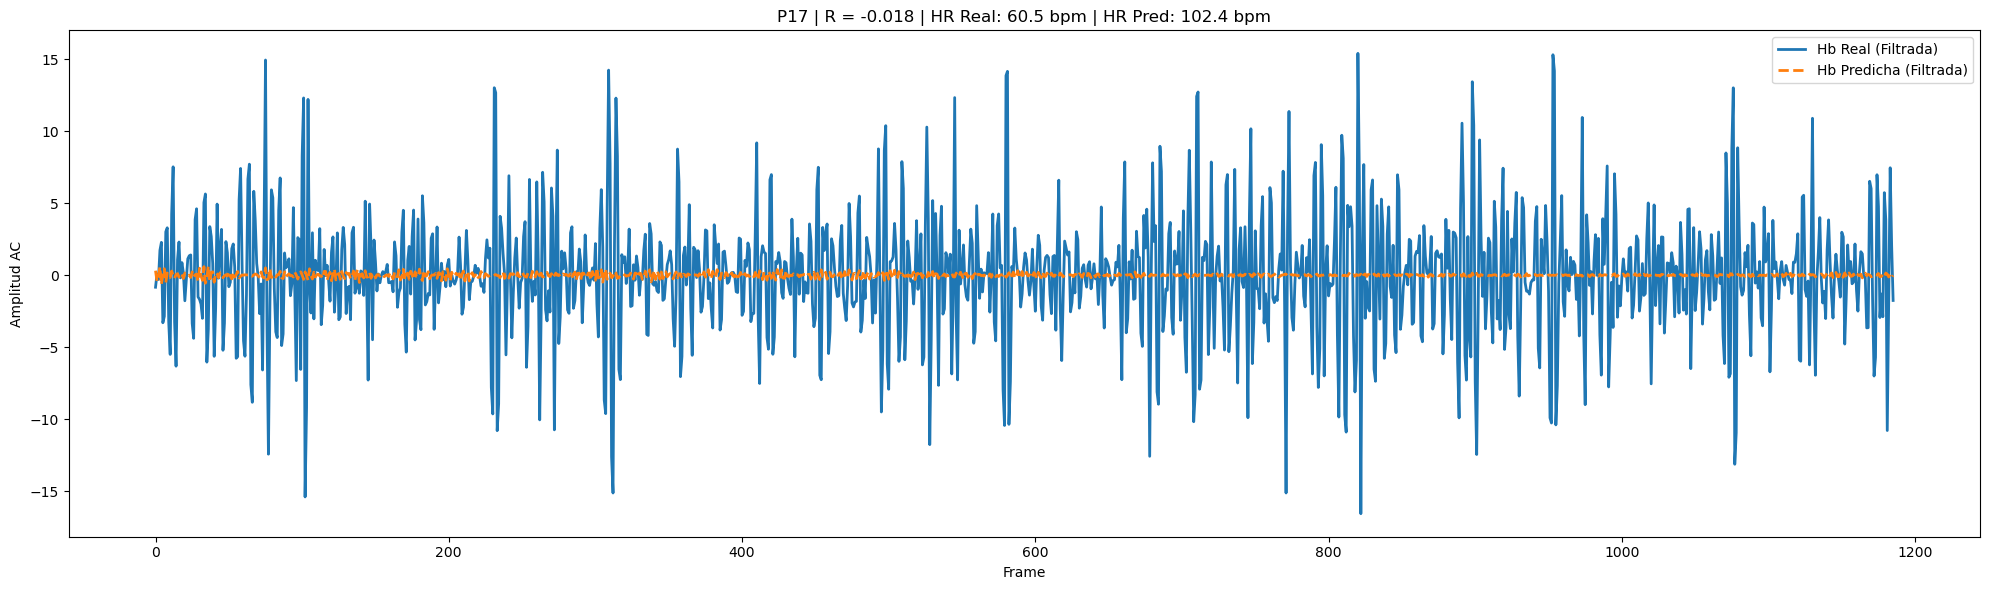

P17          | R=-0.018 | R_nulo=0.025 | R_baseline=0.037 | HR Error=41.99 bpm


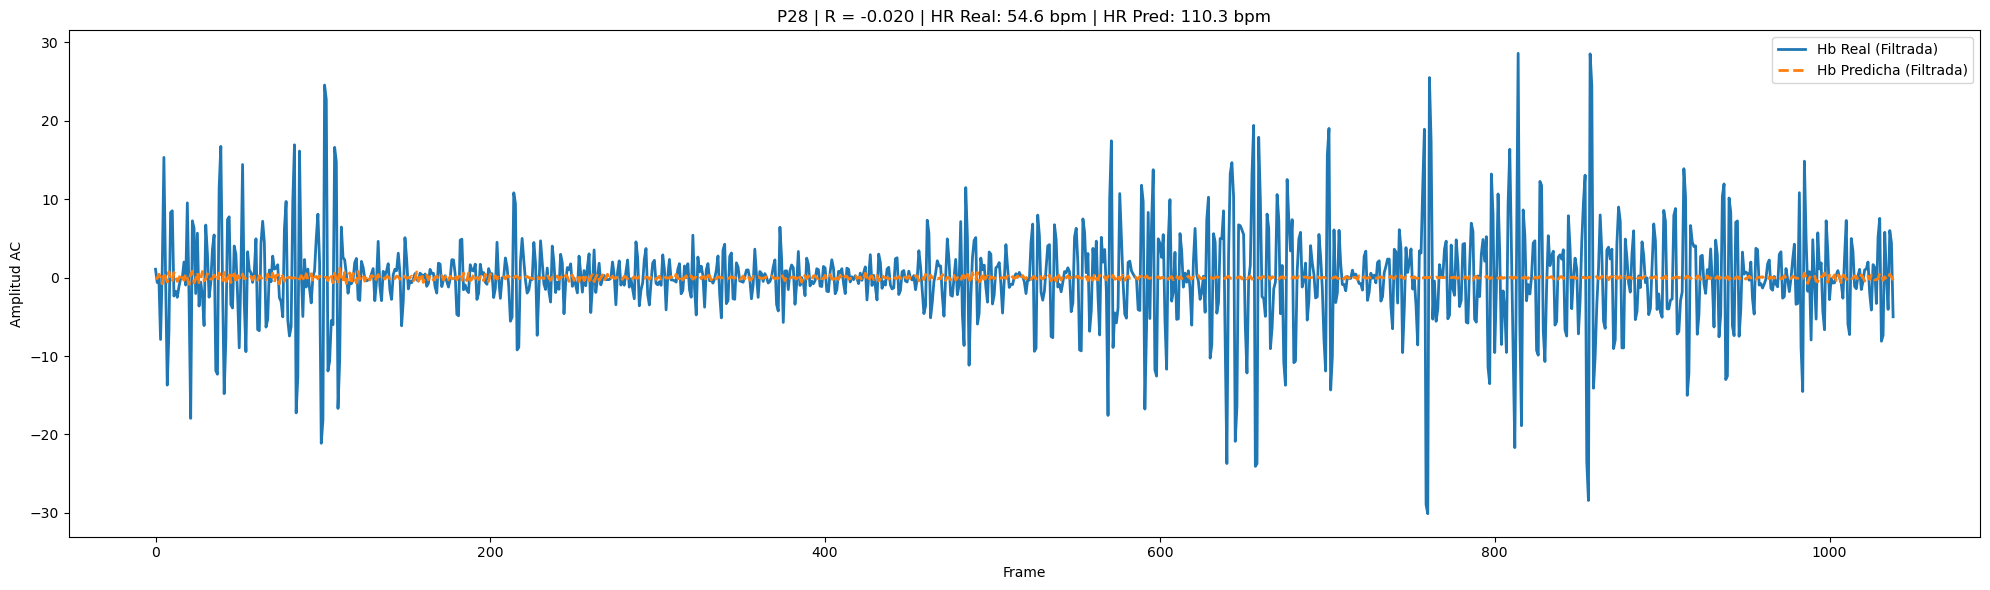

P28          | R=-0.020 | R_nulo=0.023 | R_baseline=0.035 | HR Error=55.73 bpm


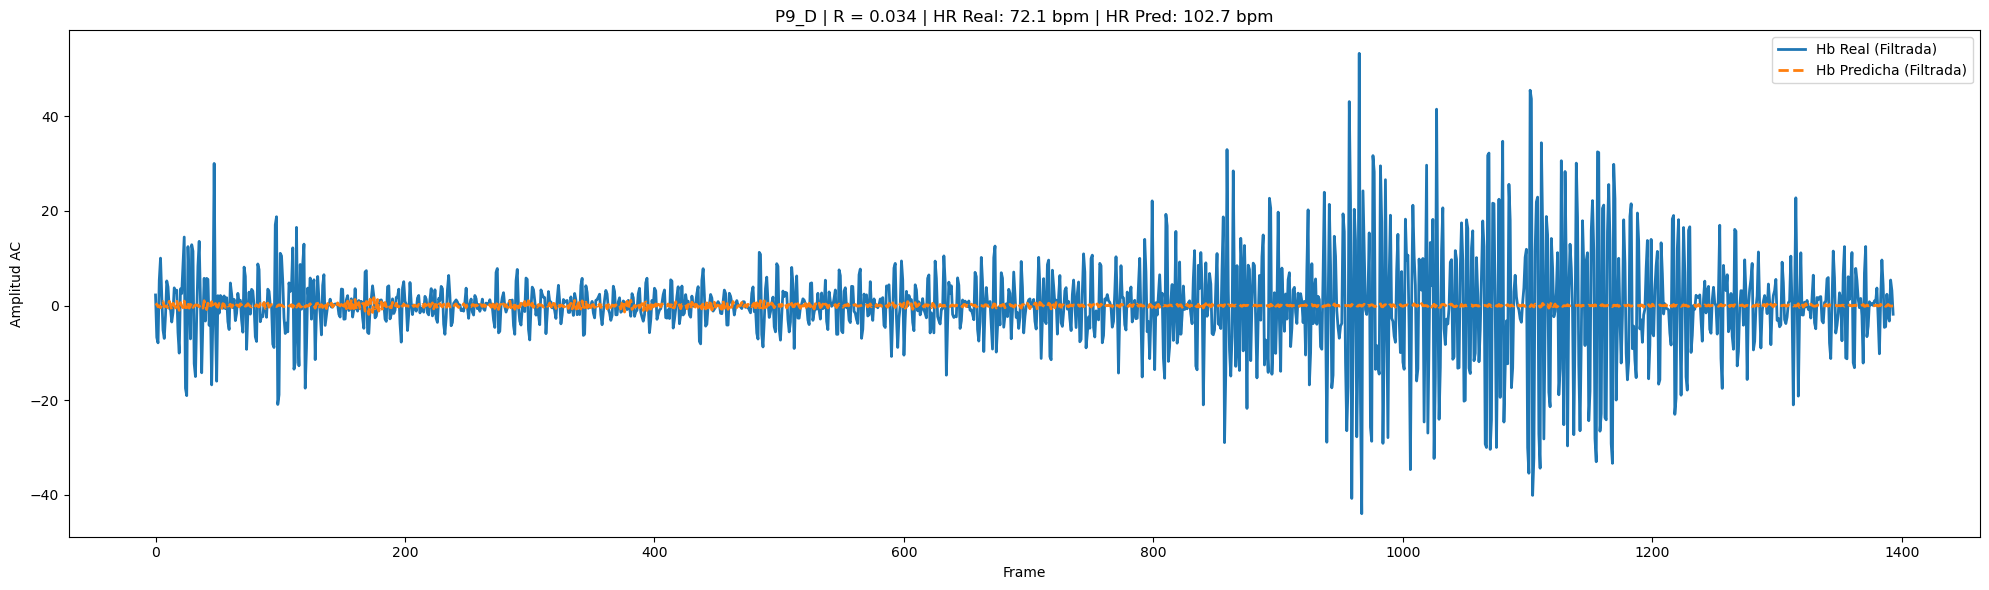

P9_D         | R=0.034 | R_nulo=-0.002 | R_baseline=-0.006 | HR Error=30.56 bpm

Zonas evaluadas         : ROI_1=z2, ROI_2=z3
Participantes evaluados : 3
Pearson R global        : 0.0167
R nulo (promedio)       : 0.0151  <- referencia de ruido
R baseline (promedio)   : 0.0221  <- referencia sin entrenar
Wave MAE global         : 4.73668
Wave RMSE global        : 7.45629
HR MAE                  : 42.7587 bpm
HR RMSE                 : 43.9791 bpm
Precision @ 2.5 bpm     : 0.00%
Precision @ 5.0 bpm     : 0.00%


In [ ]:
def main():
    cfg = Config()
    tf.keras.utils.set_random_seed(cfg.seed)
    for gpu in tf.config.list_physical_devices("GPU"):
        tf.config.experimental.set_memory_growth(gpu, True)
    os.makedirs(cfg.output_dir, exist_ok=True)

    files = {s: list_split(cfg, s) for s in ("train", "val", "test")}
    print({s: len(f) for s, f in files.items()})
    
    if not files["train"]:
        print("ERROR: No se encontraron archivos en train.")
        return
        
    check_keys(cfg, files["train"])

    groups = {s: group_by_participant(f) for s, f in files.items()}
    print({s: len(g) for s, g in groups.items()}, "participantes por conjunto")

    band_mean = compute_band_means(cfg, groups["train"])
    tables = {s: build_table(cfg, g, band_mean) for s, g in groups.items()}

    train_ds = make_dataset(cfg, tables["train"], band_mean, shuffle=True)
    val_ds = make_dataset(cfg, tables["val"], band_mean, shuffle=False)

    input_shape = (cfg.timesteps, cfg.patch, cfg.patch, cfg.bands)
    model = crear_modelo(input_shape, learning_rate=cfg.lr)
    model.summary()

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, verbose=1),
        ModelCheckpoint(os.path.join(cfg.output_dir, "mejor_modelo_ex2.weights.h5"),
                        monitor="val_loss", save_best_only=True,
                        save_weights_only=True, verbose=1),
        CSVLogger(os.path.join(cfg.output_dir, "log_entrenamiento_ex2.csv")),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=cfg.epochs, callbacks=callbacks)
    plot_history(cfg, history)

    results = evaluate_test(cfg, model, tables["test"], band_mean)

    lines = [
        f"Zonas evaluadas         : ROI_1={cfg.zones[0]}, ROI_2={cfg.zones[1]}",
        f"Participantes evaluados : {results['n_participants']}",
        f"Pearson R global        : {results['pearson']:.4f}",
        f"R nulo (promedio)       : {results['null_r_mean']:.4f}  <- referencia de ruido",
        f"R baseline (promedio)   : {results['baseline_r_mean']:.4f}  <- referencia sin entrenar",
        f"Wave MAE global         : {results['mae']:.5f}",
        f"Wave RMSE global        : {results['rmse']:.5f}",
        f"HR MAE                  : {results['hr_mae']:.4f} bpm",
        f"HR RMSE                 : {results['hr_rmse']:.4f} bpm",
        f"Precision @ 2.5 bpm     : {results['precision_2_5'] * 100:.2f}%",
        f"Precision @ 5.0 bpm     : {results['precision_5_0'] * 100:.2f}%",
    ]
    print("\n" + "=" * 100 + "\n" + "\n".join(lines))
    with open(os.path.join(cfg.output_dir, "metricas_finales_ex2.txt"), "w") as f:
        f.write("\n".join(lines) + "\n")

if __name__ == "__main__":
    main()

## Análisis 

Los resultados obtenidos muestran un fracaso en el rendimiento del modelo, ya que este no logró aprender la dinámica rPPG ni estimar la frecuencia cardíaca de forma correcta a pesar de utilizar la totalidad de las 42 bandas espectrales. A continuación se desglosa el porqué de cada métrica deficiente:

### 1. Correlación de Pearson ($R = 0.0167$ vs. Baselines)
* Un coeficiente de correlación $R$ cercano a $0$ (en este caso $0.0167$) indica que no existe ninguna relación lineal entre la onda predicha por la red y la señal real de referencia del dedo gordo.
* Lo alarmante es que el *R global* ($0.0167$) es prácticamente idéntico al *R nulo* ($0.0151$) y al *R baseline* ($0.0221$). Esto demuestra que el modelo entrenado se comporta igual que un modelo sin entrenar o que un número aleatorio. La red no aprendió nada útil durante las épocas de entrenamiento; sus pesos internos no lograron capturar la onda de pulso.

### 2. Error de Frecuencia Cardíaca ($\text{HR MAE} = 42.76\text{ bpm}$ y $\text{HR RMSE} = 43.98\text{ bpm}$)
* Un error medio absoluto en la frecuencia cardíaca de más de $42\text{ bpm}$ en humanos es catastrófico. Si un paciente real tiene una frecuencia cardíaca en reposo de $75\text{ bpm}$, el modelo está arrojando estimaciones erróneas que oscilan entre $33\text{ bpm}$ y $117\text{ bpm}$.
* Esto confirma que la Transformada Rápida de Fourier (FFT) aplicada sobre la señal predicha está detectando ruido aleatorio de alta o baja frecuencia en lugar de aislar el pico armónico del ritmo cardíaco real dentro de la banda fisiológica ($0.7\text{ Hz} - 2.0\text{ Hz}$).

### 3. Precisión Estricta del $0.00\%$ ($\pm 2.5\text{ bpm}$ y $\pm 5.0\text{ bpm}$)
* El porcentaje de acierto en los umbrales clínicos estrictos es del $0\%$ absoluto. 
* Significa que ni una sola de las muestras evaluadas en los participantes cayó dentro del margen de error aceptable clínicamente. Las predicciones de frecuencia cardíaca están completamente desalineadas de la realidad fisiológica.


1. **Saturación o maldición de la dimensionalidad con 42 bandas:** Contrario a la hipótesis de que faltaban canales, utilizar las 42 bandas completas incrementa exponencialmente la complejidad del espacio de entrada y la cantidad de ruido espectral irrelevante. 
2. **Tasa de aprendizaje inadecuada:** Con una una función de pérdida basada en Pearson ($1 - r$), si el *learning rate* (`lr = 1e-4`) no es el óptimo o si el tamaño del lote (`batch_size = 32`) con pocos participantes ($3$ evaluados en test de una cohorte limitada) genera gradientes inestables, la red se estanca en un mínimo local plano donde predecir una línea casi plana o ruido minimiza falsamente la pérdida sin aprender.
3. **Sobreajuste o falta de generalización:** Evaluar con solo 3 participantes en esta fase de prueba deja a la red expuesta a variaciones que los sujetos de entrenamiento no permitieron generalizar adecuadamente.